# Verify EMPCA Component Interpretation

This notebook validates interpretation of learned EMPCA components under the **actual training-domain pipeline**:

1. baseline correction
2. `ti_rfft` transform
3. weighted EMPCA in transformed space

It avoids strict equality claims and emphasizes **dominant alignment + subspace equivalence**.


## A. Setup and Imports

In [18]:
# A0. Config (edit here)
from pathlib import Path

MODEL_PATH = Path('wk3/models/PSD_run1_sum_mmc.pkl')
TEMPLATE_PATH = Path('reusable/template/QP_template.npy')

# Optional: cap number of traces loaded for expensive sections.
MAX_TRACES = 1200

# If traces are unavailable locally, notebook still runs and marks trace-dependent sections as skipped.
RUN_EXPENSIVE = True
RUN_STABILITY_SECTION = True

# Finite-difference / perturbation settings
SHIFT_SAMPLES = list(range(-24, 25, 2))
SHAPE_ALPHA = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25]

# Derivative scale (used in np.gradient). If unknown, keep 1.0 for relative mode.
FS_HZ = 1.0

print('MODEL_PATH =', MODEL_PATH)
print('TEMPLATE_PATH =', TEMPLATE_PATH)

TIMING_MAX_TRACES = 300
TIMING_MAX_LAG = 256


MODEL_PATH = wk3/models/PSD_run1_sum_mmc.pkl
TEMPLATE_PATH = reusable/template/QP_template.npy


In [19]:
# A1/A2/A3. Imports + project path handling
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy import linalg
from scipy.interpolate import interp1d

start = Path.cwd().resolve()
repo_root = None
for cand in (start, *start.parents):
    if (cand / 'wk3' / 'models').exists() and (cand / 'reusable').exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate repo root containing wk3/models and reusable')

sys.path.insert(0, str(repo_root / 'reusable'))
from empca_TCY_optimized import ti_rfft, ti_irfft

MODEL_PATH_ABS = (repo_root / MODEL_PATH).resolve() if not MODEL_PATH.is_absolute() else MODEL_PATH
TEMPLATE_PATH_ABS = (repo_root / TEMPLATE_PATH).resolve() if not TEMPLATE_PATH.is_absolute() else TEMPLATE_PATH

print('repo_root:', repo_root)
print('model path abs:', MODEL_PATH_ABS)
print('template path abs:', TEMPLATE_PATH_ABS)


repo_root: /home/dwong/DELight_mtr/PCA_dev
model path abs: /home/dwong/DELight_mtr/PCA_dev/wk3/models/PSD_run1_sum_mmc.pkl
template path abs: /home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy


## B. Load Saved Model Artifact

In [20]:
# B1/B2/B3. Load artifact and extract core fields
with open(MODEL_PATH_ABS, 'rb') as f:
    artifact = pickle.load(f)

if not isinstance(artifact, dict):
    raise TypeError('Expected artifact dict as saved by training script')

required_keys = ['pca', 'cfg']
for k in required_keys:
    if k not in artifact:
        raise KeyError(f'Missing expected artifact key: {k}')

pca = artifact['pca']
cfg = artifact['cfg']
weight_type = artifact.get('weight_type', 'unknown')
noise_type = artifact.get('noise_type', 'unknown')
psd_eff = artifact.get('psd_eff', None)
snr2_weight_path = artifact.get('snr2_weight_path', None)
dataset_paths = artifact.get('dataset_paths', [])
trace_key = artifact.get('trace_key', 'traces')
keep_mask = artifact.get('keep_mask', None)

U = np.asarray(getattr(pca, 'eigvec', getattr(pca, 'components_', None)), dtype=complex)
if U is None:
    raise AttributeError('PCA object has neither eigvec nor components_')
C_saved = np.asarray(getattr(pca, 'coeff', np.empty((0, 0))), dtype=complex)

print('artifact keys:', sorted(artifact.keys()))
print('weight_type:', weight_type)
print('noise_type:', noise_type)
print('trace_key:', trace_key)
print('n dataset_paths:', len(dataset_paths))
print('keep_mask:', None if keep_mask is None else keep_mask.shape)
print('U shape:', U.shape)
print('C_saved shape:', C_saved.shape)
if psd_eff is not None:
    print('psd_eff shape:', np.asarray(psd_eff).shape)
if snr2_weight_path is not None:
    print('snr2_weight_path:', snr2_weight_path)


artifact keys: ['cfg', 'dataset', 'dataset_paths', 'energy_ev', 'keep_mask', 'n_batches', 'noise_type', 'pca', 'psd_eff', 'psd_path', 'trace_key', 'weight_type']
weight_type: 1/PSD
noise_type: mmc
trace_key: traces_MMC
n dataset_paths: 10
keep_mask: (1000,)
U shape: (4, 16385)
C_saved shape: (735, 4)
psd_eff shape: (16385,)


## C. Reconstruct Training-Domain Context

In [21]:
# C1. Load representative traces using training-style metadata

def load_traces_from_artifact(artifact_dict, max_traces=1200):
    paths = artifact_dict.get('dataset_paths', [])
    trace_key_local = artifact_dict.get('trace_key', 'traces')
    if not paths:
        return None, f'No dataset_paths in artifact.'

    blocks = []
    loaded = 0
    for p in paths:
        fp = Path(p)
        if not fp.exists():
            continue
        with h5py.File(fp, 'r') as f:
            if trace_key_local not in f:
                continue
            arr = np.asarray(f[trace_key_local][:], dtype=float)
            # training expects (N,1,T) then uses [:,0,:]
            if arr.ndim == 3:
                arr = arr[:, 0, :]
            elif arr.ndim != 2:
                continue
            remain = max_traces - loaded
            if remain <= 0:
                break
            take = min(remain, arr.shape[0])
            blocks.append(arr[:take])
            loaded += take
            if loaded >= max_traces:
                break

    if not blocks:
        return None, f'No readable local files for key={trace_key_local}.'
    return np.concatenate(blocks, axis=0), None

X_time, trace_load_err = load_traces_from_artifact(artifact, max_traces=MAX_TRACES)
if X_time is None:
    print('Trace load skipped:', trace_load_err)
else:
    print('Loaded X_time:', X_time.shape)


Loaded X_time: (1000, 32768)


In [22]:
# C2. Apply same preprocessing: baseline correction then ti_rfft

def baseline_correct_per_trace(X, pretrigger=4000, method='mean'):
    X = np.asarray(X, dtype=float)
    pre = X[:, :pretrigger]
    if method == 'median':
        b = np.median(pre, axis=1)
    else:
        b = np.mean(pre, axis=1)
    return X - b[:, None], b

if X_time is not None:
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')
    X0, baselines = baseline_correct_per_trace(X_time, pretrigger=pretrigger, method=baseline_method)
    Xf = np.asarray(ti_rfft(X0), dtype=complex)
    print('Xf shape:', Xf.shape)
else:
    X0, baselines, Xf = None, None, None


Xf shape: (1000, 16385)


In [23]:
# C3. Rebuild training-consistent weights W

def resolve_weight_vector(artifact_dict, repo):
    n_freq = U.shape[1]
    wt = artifact_dict.get('weight_type', 'unknown')

    if wt == '1/PSD':
        if 'psd_eff' not in artifact_dict:
            raise KeyError('weight_type=1/PSD but psd_eff missing')
        psd = np.asarray(artifact_dict['psd_eff'], dtype=float)
        W = 1.0 / np.maximum(psd, 1e-30)
    elif 'snr2_weight_path' in artifact_dict:
        wp = Path(artifact_dict['snr2_weight_path'])
        if not wp.is_absolute():
            wp = (repo / wp).resolve()
        if not wp.exists():
            raise FileNotFoundError(f'snr2 weight path missing: {wp}')
        W = np.asarray(np.load(wp), dtype=float)
    else:
        raise RuntimeError('Cannot determine weights from artifact')

    if len(W) != n_freq:
        raise ValueError(f'Weight length mismatch: len(W)={len(W)}, n_freq={n_freq}')
    return W

W = resolve_weight_vector(artifact, repo_root)
print('W shape:', W.shape, 'min/max:', float(np.min(W)), float(np.max(W)))


W shape: (16385,) min/max: 727.770933918662 582032.7218170777


## D. Metric + Projection Helpers

In [24]:
# D1/D2/D3. Weighted metric helpers + projection + sign/phase alignment

def weighted_inner(a, b, w):
    a = np.asarray(a, dtype=complex).ravel()
    b = np.asarray(b, dtype=complex).ravel()
    w = np.asarray(w, dtype=float).ravel()
    return np.sum(np.conj(a) * w * b)


def weighted_norm(a, w):
    v = np.real(weighted_inner(a, a, w))
    return np.sqrt(max(v, 0.0))


def weighted_cosine(a, b, w):
    den = weighted_norm(a, w) * weighted_norm(b, w)
    if den <= 0:
        return np.nan + 0j
    return weighted_inner(a, b, w) / den


def normalize_weighted(a, w, eps=1e-30):
    n = weighted_norm(a, w)
    if n < eps:
        return np.asarray(a, dtype=complex)
    return np.asarray(a, dtype=complex) / n


def weighted_ls(B, y, w, ridge=1e-18):
    # B: (n, p), y: (n,), w: (n,)
    B = np.asarray(B, dtype=complex)
    y = np.asarray(y, dtype=complex)
    w = np.asarray(w, dtype=float)
    G = B.conj().T @ (w[:, None] * B)
    G = G + ridge * np.eye(G.shape[0], dtype=complex)
    rhs = B.conj().T @ (w * y)
    c = np.linalg.solve(G, rhs)
    yhat = B @ c
    return c, yhat


def weighted_r2(y, yhat, w):
    e = y - yhat
    sse = np.real(weighted_inner(e, e, w))
    sst = np.real(weighted_inner(y, y, w))
    return 1.0 - sse / max(sst, 1e-30), np.sqrt(max(sse, 0.0))


def align_phase_to_ref(v, ref, w):
    # Multiply by unit phase so weighted_inner(ref, v) has max real part.
    z = weighted_inner(ref, v, w)
    if np.abs(z) < 1e-30:
        return v
    return v * np.exp(-1j * np.angle(z))


def weighted_principal_angles(Ub, Rb, w):
    # Ub/Rb: rows are basis vectors (k, n)
    sqrtw = np.sqrt(w)
    Uw = (sqrtw[None, :] * Ub).T
    Rw = (sqrtw[None, :] * Rb).T
    Qu, _ = np.linalg.qr(Uw)
    Qr, _ = np.linalg.qr(Rw)
    s = np.linalg.svd(Qu.conj().T @ Qr, compute_uv=False)
    s = np.clip(np.real(s), -1.0, 1.0)
    return np.degrees(np.arccos(s))


## E. Build Physical Reference Candidates (Training Domain)

In [25]:
# E1/E2. Template + derivative candidates

template_time = np.asarray(np.load(TEMPLATE_PATH_ABS), dtype=float).ravel()

# Candidate template in transformed domain
r_template_time = template_time.copy()
r_template_freq = np.asarray(ti_rfft(r_template_time), dtype=complex).ravel()

# Helper to shift in time domain using interpolation

def shift_signal(x, shift_samples):
    n = len(x)
    t = np.arange(n)
    f = interp1d(t, x, kind='cubic', bounds_error=False, fill_value=(x[0], x[-1]))
    return f(t - shift_samples)

# Derivative candidate 1: raw numerical derivative in time domain
dt = 1.0 / FS_HZ
d1_time = np.gradient(template_time, dt)
d1_freq = np.asarray(ti_rfft(d1_time), dtype=complex).ravel()

# Derivative candidate 2: finite-shift derivative in time domain
delta = 1.0
d2_time = (shift_signal(template_time, +delta) - shift_signal(template_time, -delta)) / (2.0 * delta)
d2_freq = np.asarray(ti_rfft(d2_time), dtype=complex).ravel()

# Derivative candidate 3: finite-diff after transformed pipeline
s_plus_f = np.asarray(ti_rfft(shift_signal(template_time, +delta)), dtype=complex).ravel()
s_minus_f = np.asarray(ti_rfft(shift_signal(template_time, -delta)), dtype=complex).ravel()
d3_freq = (s_plus_f - s_minus_f) / (2.0 * delta)

refs_deriv = {
    'deriv_time_grad': d1_freq,
    'deriv_time_shiftfd': d2_freq,
    'deriv_freq_shiftfd': d3_freq,
}

print('template n_time:', len(template_time), 'n_freq:', len(r_template_freq), 'U n_freq:', U.shape[1])


template n_time: 32768 n_freq: 16385 U n_freq: 16385


In [26]:
# E3. Residual-shape candidates

def first_residual_shape_candidate(Xf_data, template_f, deriv_f, w):
    B = np.column_stack([
        normalize_weighted(template_f, w),
        normalize_weighted(deriv_f, w),
    ])
    R = np.empty_like(Xf_data)
    for i in range(Xf_data.shape[0]):
        _, xhat = weighted_ls(B, Xf_data[i], w)
        R[i] = Xf_data[i] - xhat
    Rc = R - np.mean(R, axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(Rc, full_matrices=False)
    return np.asarray(Vh[0], dtype=complex)


shape_candidates = {}

# Candidate 1: residual PCA mode (preferred)
best_deriv_name = None
best_deriv_val = -np.inf
u2 = U[1]
for dn, dv in refs_deriv.items():
    c = weighted_cosine(u2, dv, W)
    score = np.abs(c)
    if score > best_deriv_val:
        best_deriv_val = score
        best_deriv_name = dn

if Xf is not None and RUN_EXPENSIVE:
    shape1 = first_residual_shape_candidate(Xf, r_template_freq, refs_deriv[best_deriv_name], W)
    shape_candidates['shape_residual_pca'] = shape1
    shape_source_msg = f'shape_residual_pca from traces (n={Xf.shape[0]})'
else:
    # fallback proxy
    Btmp = np.column_stack([
        normalize_weighted(r_template_freq, W),
        normalize_weighted(refs_deriv[best_deriv_name], W),
    ])
    _, u3hat = weighted_ls(Btmp, U[2], W)
    shape_candidates['shape_residual_proxy_from_u3'] = U[2] - u3hat
    shape_source_msg = 'shape residual proxy from u3 (trace data unavailable)'

# Candidate 2: empirical morphology mode via broaden-narrow difference
def smooth_with_kernel(x, alpha):
    # positive alpha -> broader/smoother, negative -> sharpened via unsharp-like blend
    if alpha >= 0:
        k = np.array([0.25, 0.5, 0.25])
        y = x.copy()
        steps = int(1 + alpha * 12)
        for _ in range(steps):
            y = np.convolve(y, k, mode='same')
        return y
    else:
        k = np.array([0.25, 0.5, 0.25])
        y = np.convolve(x, k, mode='same')
        beta = min(0.9, abs(alpha))
        return x + beta * (x - y)

broad = smooth_with_kernel(template_time, +0.25)
narrow = smooth_with_kernel(template_time, -0.25)
shape2_time = broad - narrow
shape2_freq = np.asarray(ti_rfft(shape2_time), dtype=complex).ravel()
shape_candidates['shape_empirical_broad_minus_narrow'] = shape2_freq

print('best derivative candidate for u2 preselection:', best_deriv_name)
print('shape source:', shape_source_msg)
print('shape candidates:', list(shape_candidates.keys()))


best derivative candidate for u2 preselection: deriv_time_shiftfd
shape source: shape_residual_pca from traces (n=1000)
shape candidates: ['shape_residual_pca', 'shape_empirical_broad_minus_narrow']


## F. Verify \(u_1\) (Template-like Mode)

u1 vs template:
  weighted cosine = (0.8658830793516827-9.31121764483342e-18j)
  |weighted cosine| = 0.8658830793516827
  projection coeff = (4.754110315961435e-05+2.6371988977452756e-21j)
  R2 = 0.7497535071075523
  residual norm = 12.687770058484038


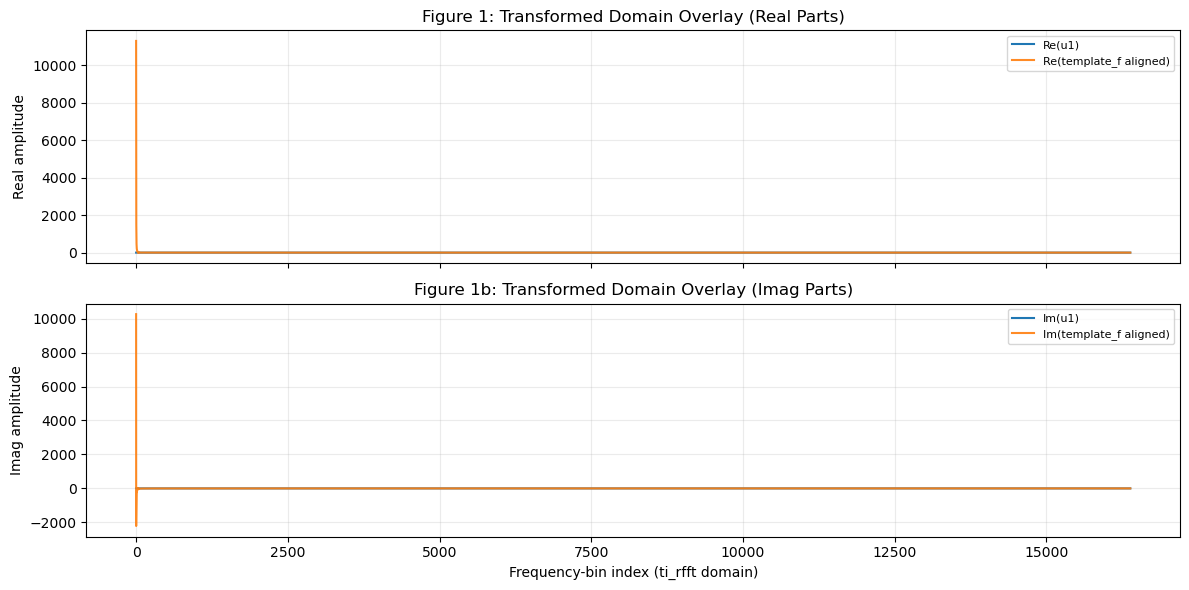

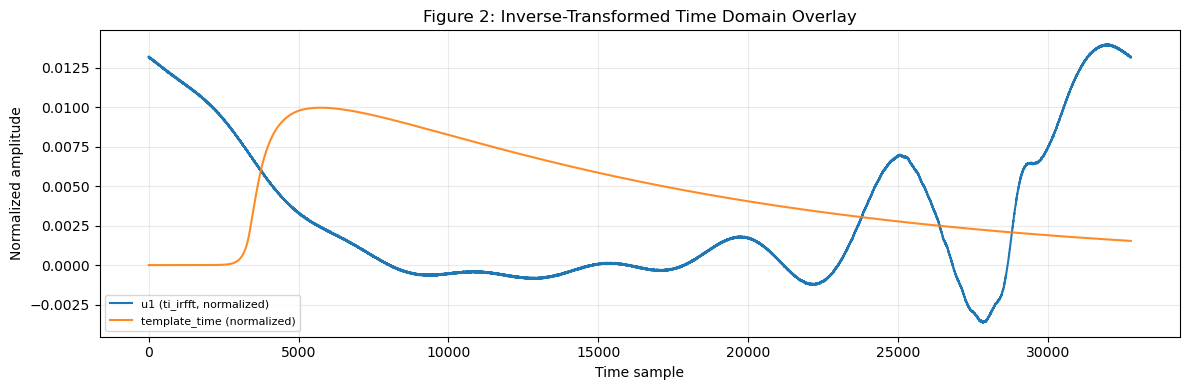

In [27]:
# F1 metrics + F2 figures
u1 = U[0]
r_t = r_template_freq

# Phase-align template reference to u1 for display + scalar metrics.
r_t_aligned = align_phase_to_ref(r_t, u1, W)

cos_u1_template = weighted_cosine(u1, r_t_aligned, W)
proj_c, proj_u1 = weighted_ls(r_t_aligned[:, None], u1, W)
r2_u1, resid_u1 = weighted_r2(u1, proj_u1, W)

print('u1 vs template:')
print('  weighted cosine =', cos_u1_template)
print('  |weighted cosine| =', abs(cos_u1_template))
print('  projection coeff =', proj_c[0])
print('  R2 =', r2_u1)
print('  residual norm =', resid_u1)

# Figure 1: transformed-domain overlay (real + imag)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(np.real(u1), label='Re(u1)')
axes[0].plot(np.real(r_t_aligned), label='Re(template_f aligned)', alpha=0.9)
axes[0].set_title('Figure 1: Transformed Domain Overlay (Real Parts)')
axes[0].set_ylabel('Real amplitude')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(np.imag(u1), label='Im(u1)')
axes[1].plot(np.imag(r_t_aligned), label='Im(template_f aligned)', alpha=0.9)
axes[1].set_title('Figure 1b: Transformed Domain Overlay (Imag Parts)')
axes[1].set_xlabel('Frequency-bin index (ti_rfft domain)')
axes[1].set_ylabel('Imag amplitude')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Figure 2: inverse transformed time-domain comparison
u1_time = np.asarray(ti_irfft(u1), dtype=float).ravel()
tpl_time = np.asarray(template_time, dtype=float).ravel()

# Normalize and sign-align for visualization only
u1n = u1_time / (np.linalg.norm(u1_time) + 1e-30)
tpn = tpl_time / (np.linalg.norm(tpl_time) + 1e-30)
if np.dot(u1n, tpn) < 0:
    u1n = -u1n

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(u1n, label='u1 (ti_irfft, normalized)')
ax.plot(tpn, label='template_time (normalized)', alpha=0.9)
ax.set_title('Figure 2: Inverse-Transformed Time Domain Overlay')
ax.set_xlabel('Time sample')
ax.set_ylabel('Normalized amplitude')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## G. Verify What \(u_2\) Actually Represents

Derivative candidate ranking for u2:
  deriv_time_shiftfd       | cos=0.6741-0.0000j | |cos|=0.6741 | R2=0.4544 | resid=20.17
  deriv_time_grad          | cos=0.6741-0.0000j | |cos|=0.6741 | R2=0.4544 | resid=20.17
  deriv_freq_shiftfd       | cos=0.2361-0.0000j | |cos|=0.2361 | R2=0.0557 | resid=26.54


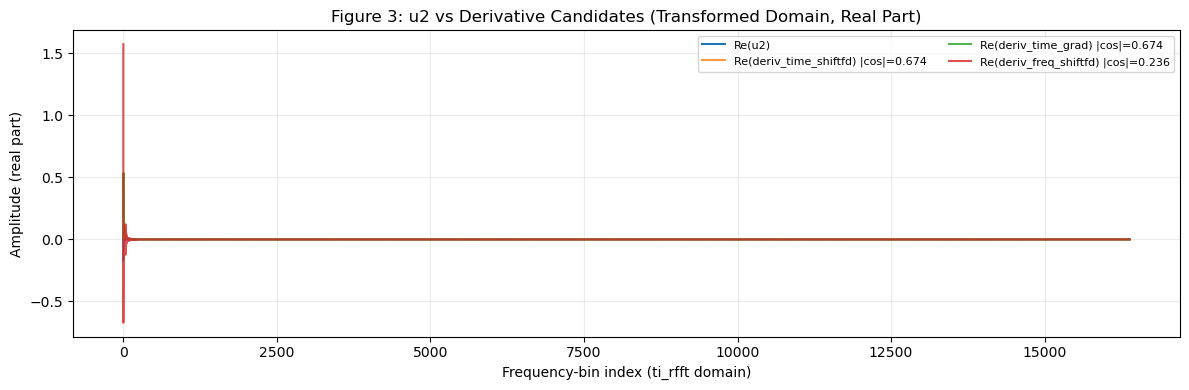

In [28]:
# G1/G2 compare u2 against all derivative candidates
u2 = U[1]

deriv_scores = []
for name, d in refs_deriv.items():
    d_aligned = align_phase_to_ref(d, u2, W)
    c = weighted_cosine(u2, d_aligned, W)
    _, yhat = weighted_ls(d_aligned[:, None], u2, W)
    r2, rn = weighted_r2(u2, yhat, W)
    deriv_scores.append((name, c, abs(c), r2, rn, d_aligned))

deriv_scores = sorted(deriv_scores, key=lambda t: t[2], reverse=True)
best_deriv = deriv_scores[0]

print('Derivative candidate ranking for u2:')
for row in deriv_scores:
    print(f'  {row[0]:24s} | cos={row[1]:.4f} | |cos|={row[2]:.4f} | R2={row[3]:.4f} | resid={row[4]:.4g}')

# Figure 3: comparison plot with all derivative candidates (real parts)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.real(u2), label='Re(u2)', linewidth=1.5)
for name, c, ac, r2, rn, d_aligned in deriv_scores:
    ax.plot(np.real(d_aligned), label=f'Re({name}) |cos|={ac:.3f}', alpha=0.8)
ax.set_title('Figure 3: u2 vs Derivative Candidates (Transformed Domain, Real Part)')
ax.set_xlabel('Frequency-bin index (ti_rfft domain)')
ax.set_ylabel('Amplitude (real part)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


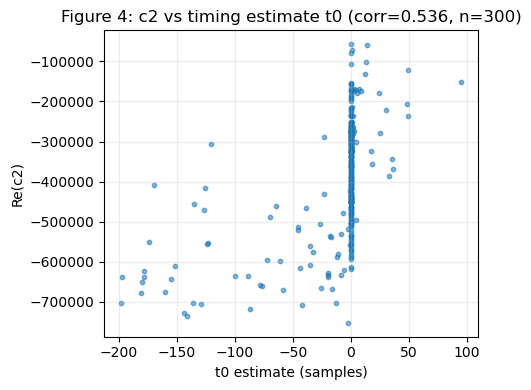

In [29]:
# G3. Timing-correlation test: c2 vs t0 (FFT-based, window-limited)

def estimate_t0_from_xcorr_fft(traces, template, max_lag=256):
    # Fast lag estimate via FFT cross-correlation; returns lag in samples within [-max_lag, +max_lag].
    traces = np.asarray(traces, dtype=float)
    t = np.asarray(template, dtype=float)
    t = t - np.mean(t)
    n = traces.shape[1]

    # FFT size for linear correlation
    nfft = 1
    while nfft < 2 * n - 1:
        nfft *= 2

    T = np.fft.rfft(t[::-1], n=nfft)
    lags = np.arange(-(n - 1), n)
    keep = (lags >= -max_lag) & (lags <= max_lag)

    out = np.zeros(traces.shape[0], dtype=float)
    for i in range(traces.shape[0]):
        x = traces[i] - np.mean(traces[i])
        X = np.fft.rfft(x, n=nfft)
        cc = np.fft.irfft(X * T, n=nfft)[: 2 * n - 1]
        ccw = cc[keep]
        lagsw = lags[keep]
        out[i] = lagsw[np.argmax(ccw)]
    return out

if Xf is None:
    print('Figure 4 skipped: traces unavailable, cannot compute c2 vs t0.')
else:
    n_use = min(TIMING_MAX_TRACES, Xf.shape[0])

    # Project traces onto first 3 EMPCA components under weighted LS
    B_u3 = U[:3].T
    coeff = np.zeros((n_use, 3), dtype=complex)
    for i in range(n_use):
        c, _ = weighted_ls(B_u3, Xf[i], W)
        coeff[i] = c

    c2 = np.real(coeff[:, 1])
    t0 = estimate_t0_from_xcorr_fft(X0[:n_use], template_time, max_lag=TIMING_MAX_LAG)
    rho = np.corrcoef(c2, t0)[0, 1]

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(t0, c2, s=10, alpha=0.55)
    ax.set_title(f'Figure 4: c2 vs timing estimate t0 (corr={rho:.3f}, n={n_use})')
    ax.set_xlabel('t0 estimate (samples)')
    ax.set_ylabel('Re(c2)')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

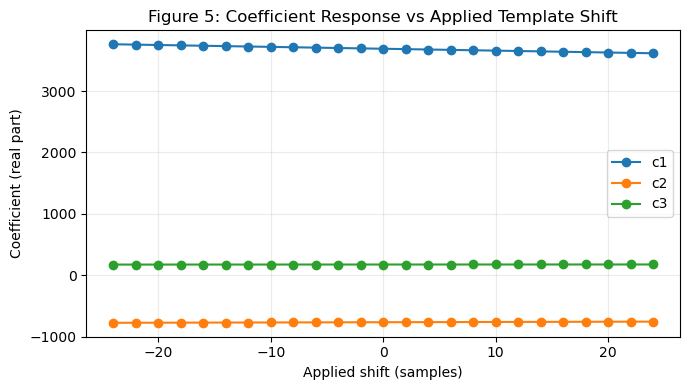

In [30]:
# G4. Perturbation test for timing: coefficient response vs applied shift

def project_on_U3(xf_vec, U3, w):
    c, _ = weighted_ls(U3.T, xf_vec, w)
    return c

U3 = U[:3]
shift_coeff = []
for sh in SHIFT_SAMPLES:
    s_shift = shift_signal(template_time, sh)
    sf = np.asarray(ti_rfft(s_shift), dtype=complex).ravel()
    c = project_on_U3(sf, U3, W)
    shift_coeff.append((sh, np.real(c[0]), np.real(c[1]), np.real(c[2])))

shift_coeff = np.asarray(shift_coeff, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shift_coeff[:, 0], shift_coeff[:, 1], '-o', label='c1')
ax.plot(shift_coeff[:, 0], shift_coeff[:, 2], '-o', label='c2')
ax.plot(shift_coeff[:, 0], shift_coeff[:, 3], '-o', label='c3')
ax.set_title('Figure 5: Coefficient Response vs Applied Template Shift')
ax.set_xlabel('Applied shift (samples)')
ax.set_ylabel('Coefficient (real part)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## H. Verify What \(u_3\) Represents

Shape candidate ranking for u3:
  shape_residual_pca               | cos=0.0767+0.0000j | |cos|=0.0767 | R2=0.0059 | resid=62.25
  shape_empirical_broad_minus_narrow | cos=0.0210+0.0000j | |cos|=0.0210 | R2=0.0004 | resid=62.42


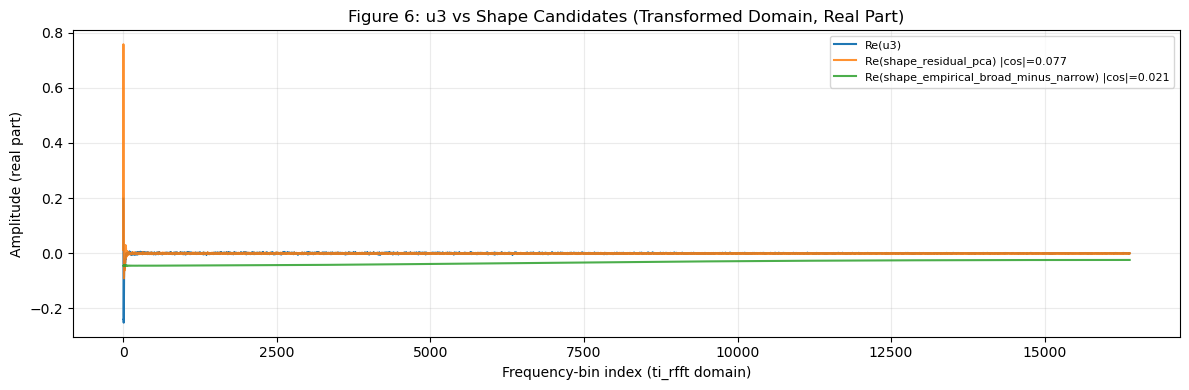

In [31]:
# H1. Compare u3 with shape candidates
u3 = U[2]
shape_scores = []
for name, s in shape_candidates.items():
    s_aligned = align_phase_to_ref(s, u3, W)
    c = weighted_cosine(u3, s_aligned, W)
    _, yhat = weighted_ls(s_aligned[:, None], u3, W)
    r2, rn = weighted_r2(u3, yhat, W)
    shape_scores.append((name, c, abs(c), r2, rn, s_aligned))
shape_scores = sorted(shape_scores, key=lambda t: t[2], reverse=True)

print('Shape candidate ranking for u3:')
for row in shape_scores:
    print(f'  {row[0]:32s} | cos={row[1]:.4f} | |cos|={row[2]:.4f} | R2={row[3]:.4f} | resid={row[4]:.4g}')

# Figure 6: u3 vs shape candidates
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.real(u3), label='Re(u3)', linewidth=1.5)
for name, c, ac, r2, rn, s_aligned in shape_scores:
    ax.plot(np.real(s_aligned), label=f'Re({name}) |cos|={ac:.3f}', alpha=0.85)
ax.set_title('Figure 6: u3 vs Shape Candidates (Transformed Domain, Real Part)')
ax.set_xlabel('Frequency-bin index (ti_rfft domain)')
ax.set_ylabel('Amplitude (real part)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


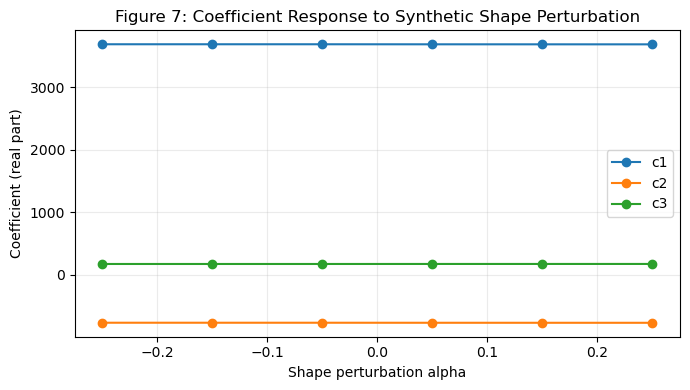

In [32]:
# H2/H3. Coefficient response to synthetic shape perturbations

def make_shape_perturbation(template, alpha):
    # alpha > 0 broadens, alpha < 0 sharpens
    y = smooth_with_kernel(template, alpha)
    return y

shape_resp = []
for a in SHAPE_ALPHA:
    s_mod = make_shape_perturbation(template_time, a)
    sf = np.asarray(ti_rfft(s_mod), dtype=complex).ravel()
    c = project_on_U3(sf, U[:3], W)
    shape_resp.append((a, np.real(c[0]), np.real(c[1]), np.real(c[2])))
shape_resp = np.asarray(shape_resp, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shape_resp[:, 0], shape_resp[:, 1], '-o', label='c1')
ax.plot(shape_resp[:, 0], shape_resp[:, 2], '-o', label='c2')
ax.plot(shape_resp[:, 0], shape_resp[:, 3], '-o', label='c3')
ax.set_title('Figure 7: Coefficient Response to Synthetic Shape Perturbation')
ax.set_xlabel('Shape perturbation alpha')
ax.set_ylabel('Coefficient (real part)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## I. Subspace Verification

Best derivative for subspace R2/R3: deriv_time_shiftfd
Best shape for subspace R3: shape_residual_pca
Weighted angles 1D/2D/3D: [30.01630516] [27.56256551 48.22943924] [21.25588129 43.74095544 77.21057457]
Euclidean angles 1D/2D/3D: [27.641986] [23.76440159 37.88581272] [ 8.81158708 27.83932367 64.21386416]


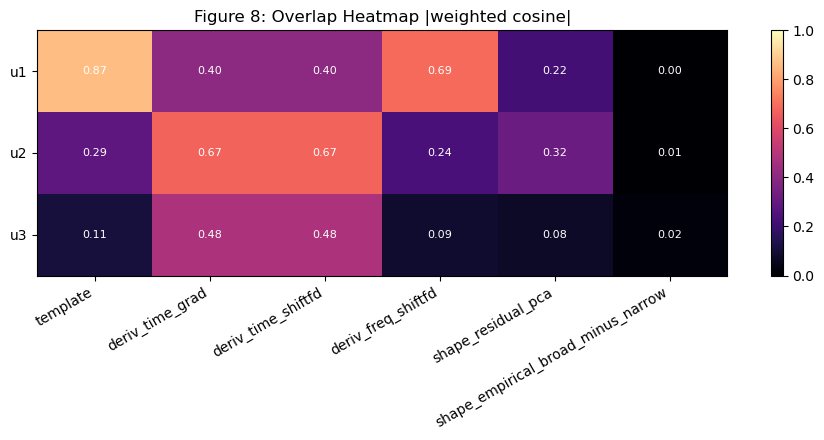

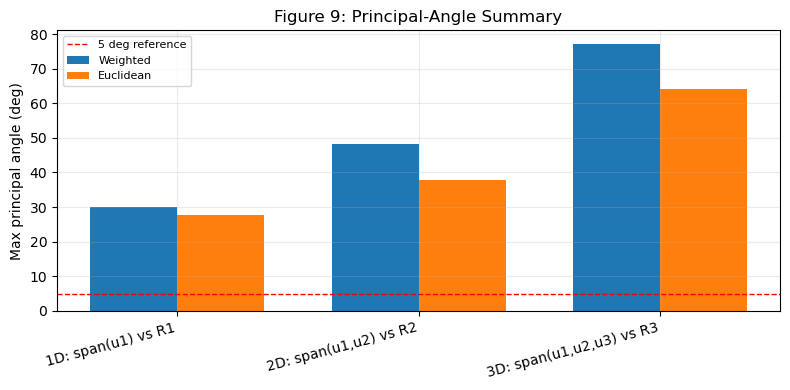

In [33]:
# I1/I2/I3. Build reference subspaces and principal-angle summaries

# Pick best derivative + best shape based on weighted cosine with u2/u3.
best_deriv_name = deriv_scores[0][0]
best_deriv_vec = deriv_scores[0][5]
best_shape_name = shape_scores[0][0]
best_shape_vec = shape_scores[0][5]

R1 = np.vstack([normalize_weighted(r_template_freq, W)])
R2 = np.vstack([normalize_weighted(r_template_freq, W), normalize_weighted(best_deriv_vec, W)])
R3 = np.vstack([normalize_weighted(r_template_freq, W), normalize_weighted(best_deriv_vec, W), normalize_weighted(best_shape_vec, W)])

U1 = np.vstack([normalize_weighted(U[0], W)])
U2s = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W)])
U3s = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W), normalize_weighted(U[2], W)])

# Weighted principal angles
ang1_w = weighted_principal_angles(U1, R1, W)
ang2_w = weighted_principal_angles(U2s, R2, W)
ang3_w = weighted_principal_angles(U3s, R3, W)

# Euclidean principal angles (W=ones)
ones_w = np.ones_like(W)
ang1_e = weighted_principal_angles(U1, R1, ones_w)
ang2_e = weighted_principal_angles(U2s, R2, ones_w)
ang3_e = weighted_principal_angles(U3s, R3, ones_w)

print('Best derivative for subspace R2/R3:', best_deriv_name)
print('Best shape for subspace R3:', best_shape_name)
print('Weighted angles 1D/2D/3D:', ang1_w, ang2_w, ang3_w)
print('Euclidean angles 1D/2D/3D:', ang1_e, ang2_e, ang3_e)

# Figure 8: overlap heatmap rows u1/u2/u3 vs references
candidate_names = ['template'] + list(refs_deriv.keys()) + list(shape_candidates.keys())
candidate_vecs = [r_template_freq] + [refs_deriv[k] for k in refs_deriv] + [shape_candidates[k] for k in shape_candidates]

H = np.zeros((3, len(candidate_names)), dtype=float)
for i in range(3):
    ui = normalize_weighted(U[i], W)
    for j, rv in enumerate(candidate_vecs):
        rvn = normalize_weighted(rv, W)
        H[i, j] = np.abs(weighted_cosine(ui, rvn, W))

fig, ax = plt.subplots(figsize=(1.2 * len(candidate_names) + 2, 4.5))
im = ax.imshow(H, aspect='auto', vmin=0, vmax=1, cmap='magma')
ax.set_yticks(np.arange(3), labels=['u1', 'u2', 'u3'])
ax.set_xticks(np.arange(len(candidate_names)), labels=candidate_names, rotation=30, ha='right')
ax.set_title('Figure 8: Overlap Heatmap |weighted cosine|')
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, f'{H[i,j]:.2f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Figure 9: principal-angle summary
labels = ['1D: span(u1) vs R1', '2D: span(u1,u2) vs R2', '3D: span(u1,u2,u3) vs R3']
vals_w = [float(np.max(ang1_w)), float(np.max(ang2_w)), float(np.max(ang3_w))]
vals_e = [float(np.max(ang1_e)), float(np.max(ang2_e)), float(np.max(ang3_e))]

x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.18, vals_w, width=0.36, label='Weighted')
ax.bar(x + 0.18, vals_e, width=0.36, label='Euclidean')
ax.set_xticks(x, labels, rotation=15, ha='right')
ax.set_ylabel('Max principal angle (deg)')
ax.set_title('Figure 9: Principal-Angle Summary')
ax.axhline(5.0, color='r', linestyle='--', linewidth=1.0, label='5 deg reference')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## J. Stability Across Models (Optional)

{'model': 'PSD_run1_sum_mmc.pkl', 'noise_type': 'mmc', 'weight_type': '1/PSD', 'u1_abs_cosine_to_ref': 1.0000000000000002, 'sub2_max_angle_deg': 2.2588727439225506e-06, 'sub3_max_angle_deg': 4.597711793052988e-06}
{'model': 'PSD_run1_sum_pink.pkl', 'noise_type': 'pink', 'weight_type': '1/PSD', 'u1_abs_cosine_to_ref': 0.999196093613782, 'sub2_max_angle_deg': 29.995885723189268, 'sub3_max_angle_deg': 77.15100368381448}
{'model': 'PSD_run1_sum_white.pkl', 'noise_type': 'white', 'weight_type': '1/PSD', 'u1_abs_cosine_to_ref': 0.9993040924511608, 'sub2_max_angle_deg': 39.52649442118188, 'sub3_max_angle_deg': 86.50608976354194}
{'model': 'SNR2_run1_sum_mmc.pkl', 'noise_type': 'mmc', 'weight_type': 'SNR2=|H|^2/PSD', 'u1_abs_cosine_to_ref': 0.9034663397930598, 'sub2_max_angle_deg': 76.44591929630633, 'sub3_max_angle_deg': 86.82809348721362}
{'model': 'SNR2_run1_sum_pink.pkl', 'noise_type': 'pink', 'weight_type': 'SNR2=|H|^2/PSD', 'u1_abs_cosine_to_ref': 0.9993440938348678, 'sub2_max_angle_deg'

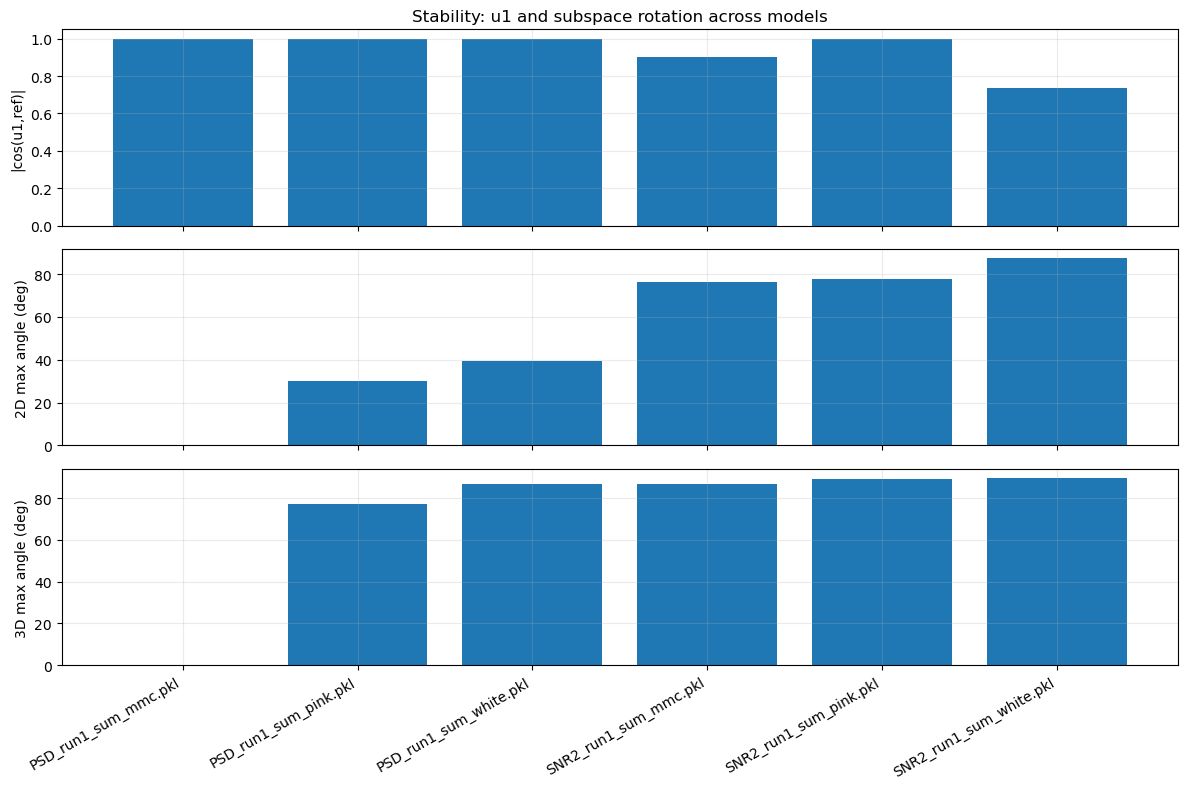

In [34]:
# J1/J2/J3. Stability metrics across available saved models
if not RUN_STABILITY_SECTION:
    print('Stability section disabled by config.')
else:
    model_files = sorted((repo_root / 'wk3' / 'models').glob('*.pkl'))
    if not model_files:
        print('No models found.')
    else:
        # Reference from selected model
        u1_ref = normalize_weighted(U[0], W)
        U2_ref = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W)])
        U3_ref = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W), normalize_weighted(U[2], W)])

        rows = []
        for mf in model_files:
            with open(mf, 'rb') as f:
                a = pickle.load(f)
            p = a['pca'] if isinstance(a, dict) and 'pca' in a else a
            Um = np.asarray(getattr(p, 'eigvec', getattr(p, 'components_', None)), dtype=complex)
            if Um is None or Um.shape[0] < 3:
                continue

            # Resolve model-specific Wm
            try:
                Wm = resolve_weight_vector(a, repo_root)
            except Exception:
                continue

            u1m = normalize_weighted(Um[0], Wm)
            # compare u1 in reference metric approximately by resampling not needed (same n_freq expected)
            c1 = weighted_cosine(u1_ref, align_phase_to_ref(u1m, u1_ref, W), W)

            U2m = np.vstack([normalize_weighted(Um[0], Wm), normalize_weighted(Um[1], Wm)])
            U3m = np.vstack([normalize_weighted(Um[0], Wm), normalize_weighted(Um[1], Wm), normalize_weighted(Um[2], Wm)])
            a2 = weighted_principal_angles(U2_ref, U2m, W)
            a3 = weighted_principal_angles(U3_ref, U3m, W)

            rows.append({
                'model': mf.name,
                'noise_type': a.get('noise_type', 'unknown') if isinstance(a, dict) else 'unknown',
                'weight_type': a.get('weight_type', 'unknown') if isinstance(a, dict) else 'unknown',
                'u1_abs_cosine_to_ref': float(abs(c1)),
                'sub2_max_angle_deg': float(np.max(a2)),
                'sub3_max_angle_deg': float(np.max(a3)),
            })

        if not rows:
            print('No comparable models for stability metrics.')
        else:
            rows = sorted(rows, key=lambda d: d['model'])
            for r in rows:
                print(r)

            # compact stability figure
            names = [r['model'] for r in rows]
            u1v = [r['u1_abs_cosine_to_ref'] for r in rows]
            a2v = [r['sub2_max_angle_deg'] for r in rows]
            a3v = [r['sub3_max_angle_deg'] for r in rows]

            x = np.arange(len(names))
            fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
            axes[0].bar(x, u1v)
            axes[0].set_ylabel('|cos(u1,ref)|')
            axes[0].set_ylim(0, 1.05)
            axes[0].set_title('Stability: u1 and subspace rotation across models')
            axes[0].grid(alpha=0.25)

            axes[1].bar(x, a2v)
            axes[1].set_ylabel('2D max angle (deg)')
            axes[1].grid(alpha=0.25)

            axes[2].bar(x, a3v)
            axes[2].set_ylabel('3D max angle (deg)')
            axes[2].set_xticks(x, names, rotation=30, ha='right')
            axes[2].grid(alpha=0.25)

            plt.tight_layout()
            plt.show()


## Interpretation Summary

Use the metrics and figures above to answer:

1. Is `u1` strongly template-like in the transformed domain?
2. Is `u2` best interpreted as derivative-like / timing-like, or more generally as first residual morphology mode?
3. Is `u3` shape-like, mixed, or weakly identifiable?
4. Does low-dimensional EMPCA subspace alignment support the intended physical interpretation?
5. Which claims are safe for the paper, and which are too strong?

Guidance for safe wording:

- Prefer: "dominant alignment" and "subspace equivalence".
- Avoid: strict one-to-one or exact-equality statements for `u2`/`u3`.
- Report uncertainty explicitly when timing-correlation and perturbation-response evidence is mixed.
